# SentinelX Notebook 1: Data Exploration

## What is SentinelX?

SentinelX is a **predictive maintenance** system. It predicts when machines will fail BEFORE they actually fail.

### Why is this important?
- **Unplanned downtime costs $5,000+** per incident (production stops, emergency repairs)
- **False alarms cost $500** each (unnecessary technician visits)
- A good model saves millions by catching real failures and avoiding false alarms

### Our Data
We have **synthetic data** that simulates 5 industrial machines over ~35 days:
- **System Metrics**: CPU, memory, temperature, vibration, etc. (every 5 minutes)
- **Application Logs**: Error rates, response times, etc. (every 5 minutes)
- **Target**: `machine_failure` (0 = healthy, 1 = failure)

Let's explore this data!

In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load the Raw Data

Our data generator creates two CSV files:
- `system_metrics.csv` - Hardware sensors (temperature, vibration, etc.)
- `application_logs.csv` - Software metrics (errors, latency, etc.)

In [2]:
# Load system metrics
sys_df = pd.read_csv('../logs/system_metrics.csv', parse_dates=['timestamp'])
print(f"System Metrics: {sys_df.shape[0]:,} rows × {sys_df.shape[1]} columns")
sys_df.head()

System Metrics: 50,000 rows × 20 columns


,timestamp,machine_id,product_type,air_temperature_K,process_temperature_K,rotational_speed_rpm,torque_Nm,tool_wear_min,vibration_mm_s,pressure_psi,network_latency_ms,edge_processing_time_ms,fuzzy_pid_output,machine_failure,failure_TWF,failure_HDF,failure_PWF,failure_OSF,failure_RNF,maintenance_status
0,2024-01-01 00:00:00,M1,L,300.42,309.79,1441.0,54.48,2.6,20.395,112.96,8.607,5.743,0.8468,0,0,0,0,0,0,Normal
1,2024-01-01 00:05:00,M2,H,301.31,311.26,1424.7,47.85,2.6,19.789,106.46,8.361,5.596,0.8797,0,0,0,0,0,0,Normal
2,2024-01-01 00:10:00,M3,M,300.04,310.73,1640.6,49.78,1.0,17.637,109.73,9.246,6.035,0.9027,0,0,0,0,0,0,Normal
3,2024-01-01 00:15:00,M4,L,299.03,308.53,1263.7,56.08,2.3,14.856,110.42,13.281,10.445,0.8824,0,0,0,0,0,0,Normal
4,2024-01-01 00:20:00,M5,L,300.89,309.48,1394.3,51.25,1.5,19.512,112.86,9.938,9.571,0.9330,0,0,0,0,0,0,Normal


In [3]:
# Load application logs
app_df = pd.read_csv('../logs/application_logs.csv', parse_dates=['timestamp'])
print(f"Application Logs: {app_df.shape[0]:,} rows × {app_df.shape[1]} columns")
app_df.head()

Application Logs: 50,000 rows × 14 columns


,timestamp,machine_id,api_response_latency_ms,error_rate_pct,http_5xx_count,request_throughput_rps,queue_depth,cpu_utilization_pct,memory_utilization_pct,packet_loss_pct,disk_io_wait_ms,anomaly_score,is_anomaly,maintenance_status
0,2024-01-01 00:00:00,M1,44.46,1.0688,4,182.89,5,48.72,37.03,0.1545,4.216,0.0132,0,Normal
1,2024-01-01 00:05:00,M2,44.74,1.0803,4,185.86,4,52.46,41.09,0.1173,2.519,0.0129,0,Normal
2,2024-01-01 00:10:00,M3,45.94,0.7496,5,210.72,4,45.15,35.25,0.3482,1.911,0.0142,0,Normal
3,2024-01-01 00:15:00,M4,47.99,0.5502,2,162.90,5,34.99,37.33,0.1378,3.867,0.0204,0,Normal
4,2024-01-01 00:20:00,M5,50.17,0.6704,1,202.38,4,36.45,35.71,0.2211,3.201,0.0153,0,Normal


## 2. Understanding the Columns

### System Metrics (Hardware Sensors)
| Column | Description | Unit |
|--------|-------------|------|
| `air_temperature_K` | Ambient temperature | Kelvin |
| `process_temperature_K` | Machine internal temp | Kelvin |
| `rotational_speed_rpm` | Motor speed | RPM |
| `torque_Nm` | Motor torque | Newton-meters |
| `tool_wear_min` | Tool usage time | Minutes |
| `vibration_mm_s` | Vibration level | mm/s |
| `pressure_psi` | System pressure | PSI |
| `machine_failure` | **TARGET** | 0/1 |

In [10]:
# Check data types and missing values
print("=== System Metrics Info ===")
print(f"\nColumns: {list(sys_df.columns)}")
print(f"\nMissing values:\n{sys_df.isnull().sum()}")
print(f"\nData types:\n{sys_df.dtypes}")

=== System Metrics Info ===

Columns: ['timestamp', 'machine_id', 'product_type', 'air_temperature_K', 'process_temperature_K', 'rotational_speed_rpm', 'torque_Nm', 'tool_wear_min', 'vibration_mm_s', 'pressure_psi', 'network_latency_ms', 'edge_processing_time_ms', 'fuzzy_pid_output', 'machine_failure', 'failure_TWF', 'failure_HDF', 'failure_PWF', 'failure_OSF', 'failure_RNF', 'maintenance_status']

Missing values:
timestamp                  0
machine_id                 0
product_type               0
air_temperature_K          0
process_temperature_K      0
rotational_speed_rpm       0
torque_Nm                  0
tool_wear_min              0
vibration_mm_s             0
pressure_psi               0
network_latency_ms         0
edge_processing_time_ms    0
fuzzy_pid_output           0
machine_failure            0
failure_TWF                0
failure_HDF                0
failure_PWF                0
failure_OSF                0
failure_RNF                0
maintenance_status         0
dt

## 3. The Target Variable: Machine Failure

This is what we want to predict! Let's see how balanced/imbalanced it is.

Healthy (0): 47,395 rows (94.8%)
Failure (1): 2,605 rows (5.2%)

Imbalance ratio: 1:18


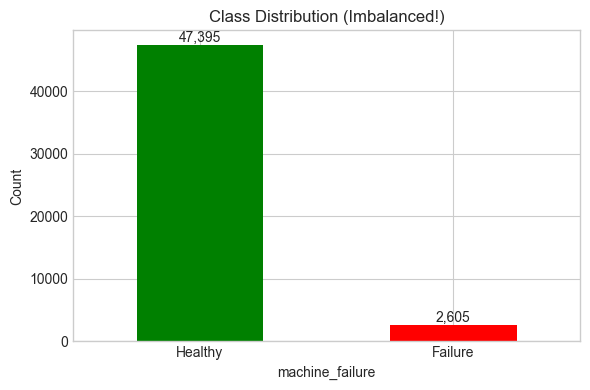

In [11]:
# Count failures vs healthy
failure_counts = sys_df['machine_failure'].value_counts()
failure_pct = sys_df['machine_failure'].mean() * 100

print(f"Healthy (0): {failure_counts[0]:,} rows ({100-failure_pct:.1f}%)")
print(f"Failure (1): {failure_counts[1]:,} rows ({failure_pct:.1f}%)")
print(f"\nImbalance ratio: 1:{failure_counts[0]//failure_counts[1]}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
failure_counts.plot(kind='bar', color=['green', 'red'], ax=ax)
ax.set_xticklabels(['Healthy', 'Failure'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Class Distribution (Imbalanced!)')
for i, v in enumerate(failure_counts):
    ax.text(i, v + 500, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

### Why Imbalance Matters

With only ~5% failures:
- A dumb model that predicts "healthy" for everything gets 95% accuracy!
- But it catches **zero** failures — useless for predictive maintenance

**Solution**: We'll use SMOTE (Synthetic Minority Oversampling) in training.

## 4. Exploring Sensor Distributions

In [12]:
# Key numeric columns
sensor_cols = ['air_temperature_K', 'rotational_speed_rpm', 'torque_Nm', 
               'tool_wear_min', 'vibration_mm_s', 'pressure_psi']

# Basic statistics
sys_df[sensor_cols].describe().round(2)

,air_temperature_K,rotational_speed_rpm,torque_Nm,tool_wear_min,vibration_mm_s,pressure_psi
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,300.02,1798.47,42.25,124.17,27.71,109.18
std,2.63,471.43,10.51,72.52,8.87,7.01
min,293.49,1058.60,9.90,0.00,6.69,83.77
25%,298.05,1462.40,33.63,61.10,20.74,104.30
50%,300.03,1556.05,44.56,124.00,25.45,109.13
75%,301.99,2353.10,50.15,186.90,33.83,114.03
max,306.74,3000.00,72.97,250.00,60.65,134.37


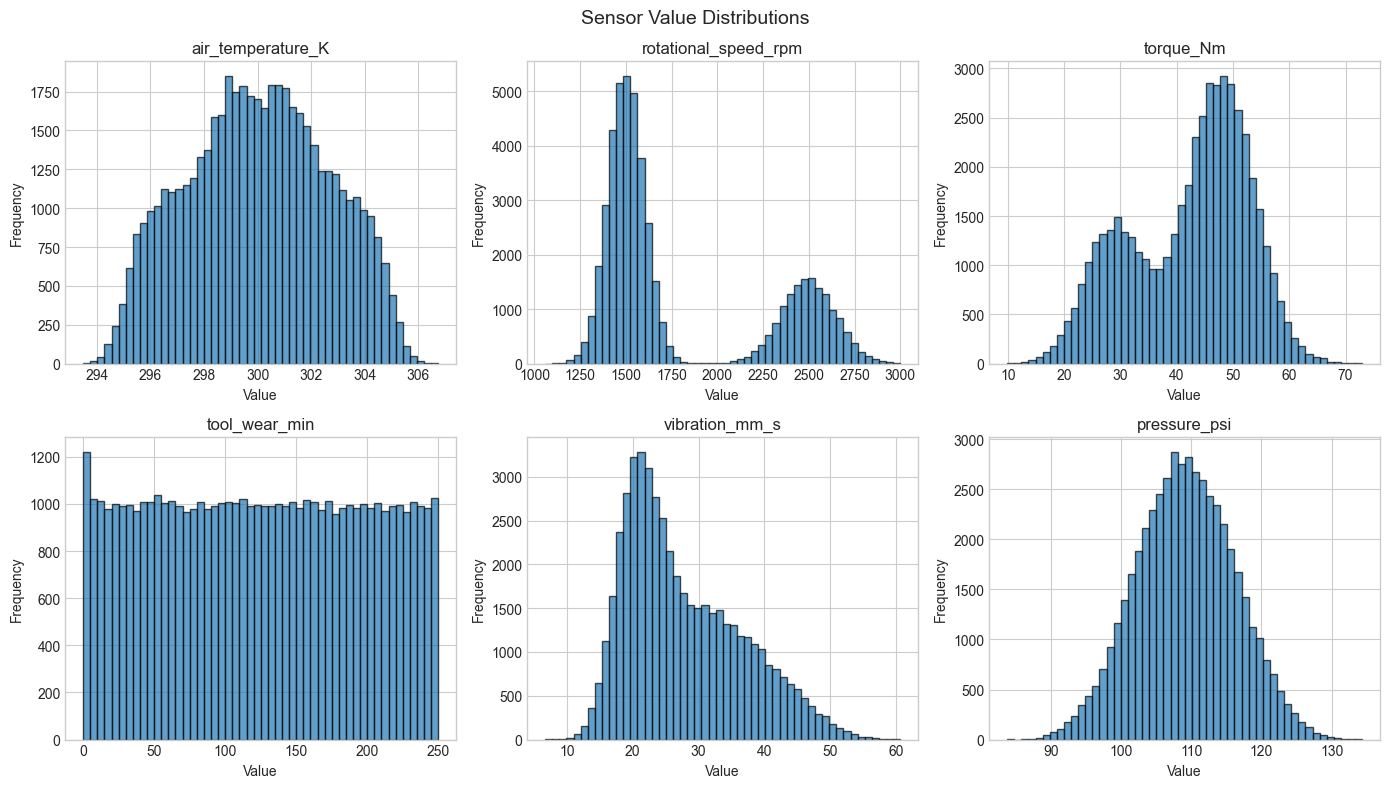

In [13]:
# Histograms of sensor values
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(sys_df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Sensor Value Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Comparing Healthy vs Failure States

Do sensor values look different when a machine is about to fail?

In [14]:
# Separate healthy and failure rows
healthy = sys_df[sys_df['machine_failure'] == 0]
failure = sys_df[sys_df['machine_failure'] == 1]

# Compare means
comparison = pd.DataFrame({
    'Healthy Mean': healthy[sensor_cols].mean(),
    'Failure Mean': failure[sensor_cols].mean(),
    'Difference %': ((failure[sensor_cols].mean() - healthy[sensor_cols].mean()) / healthy[sensor_cols].mean() * 100)
}).round(2)

print("=== Sensor Comparison: Healthy vs Failure ===")
comparison

=== Sensor Comparison: Healthy vs Failure ===


,Healthy Mean,Failure Mean,Difference %
air_temperature_K,300.02,300.00,-0.01
rotational_speed_rpm,1797.03,1824.60,1.53
torque_Nm,42.21,42.87,1.55
tool_wear_min,120.39,192.98,60.29
vibration_mm_s,26.95,41.45,53.77
pressure_psi,108.81,116.00,6.61


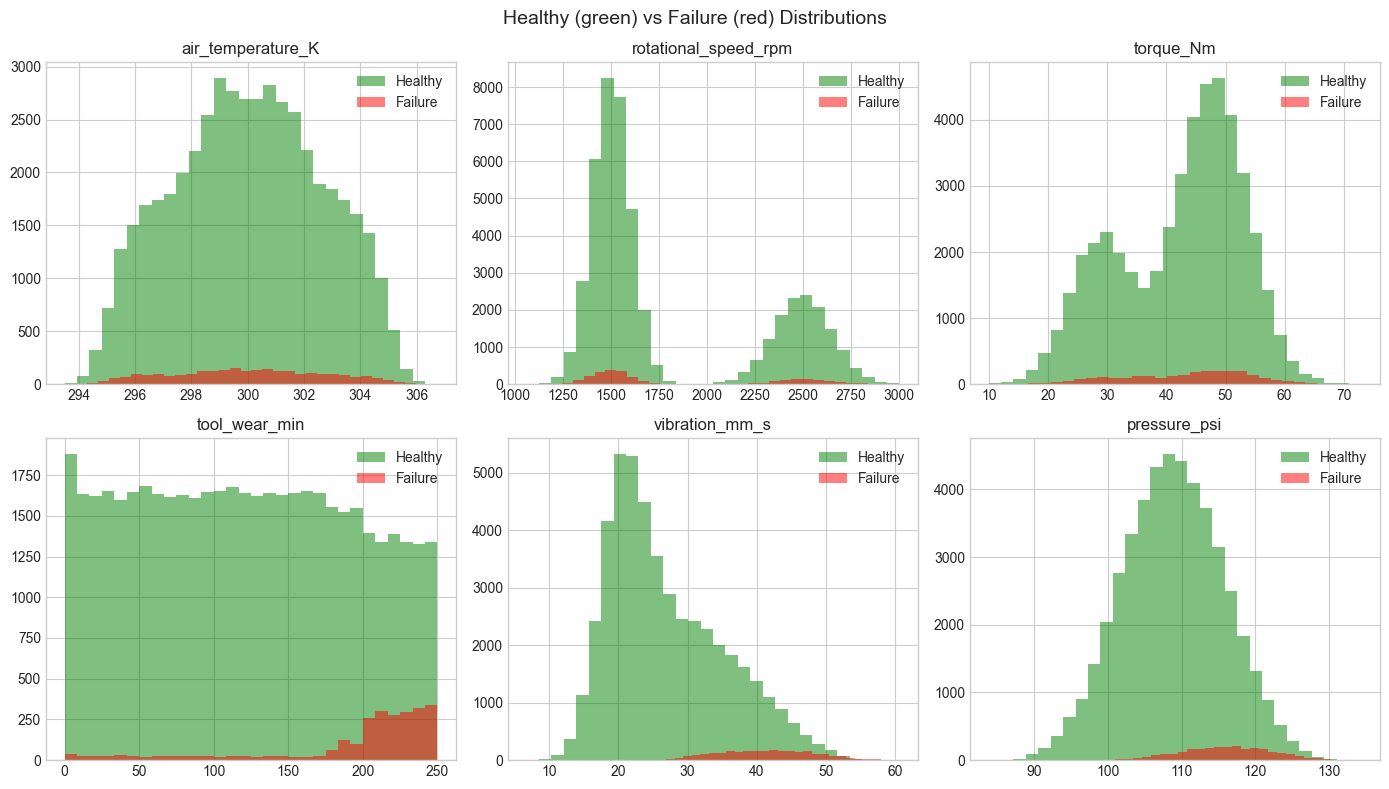

In [15]:
# Visualize the differences
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(healthy[col], bins=30, alpha=0.5, label='Healthy', color='green')
    axes[i].hist(failure[col], bins=30, alpha=0.5, label='Failure', color='red')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Healthy (green) vs Failure (red) Distributions', fontsize=14)
plt.tight_layout()
plt.show()

### Key Observations:
- **Vibration** is higher during failures (mechanical stress)
- **Temperature** tends to be elevated
- **Tool wear** is higher (worn tools cause failures)

These patterns are what our ML model will learn to recognize!

## 6. Time Series View

Let's look at one machine over time to see failure patterns.

In [16]:
# Pick one machine
machine_id = 'M1'
m1_data = sys_df[sys_df['machine_id'] == machine_id].copy()
m1_data = m1_data.set_index('timestamp')

print(f"Machine {machine_id}: {len(m1_data):,} rows")
print(f"Time range: {m1_data.index.min()} to {m1_data.index.max()}")
print(f"Failures: {m1_data['machine_failure'].sum()} events")

Machine M1: 10,000 rows
Time range: 2024-01-01 00:00:00 to 2024-06-22 14:15:00
Failures: 517 events


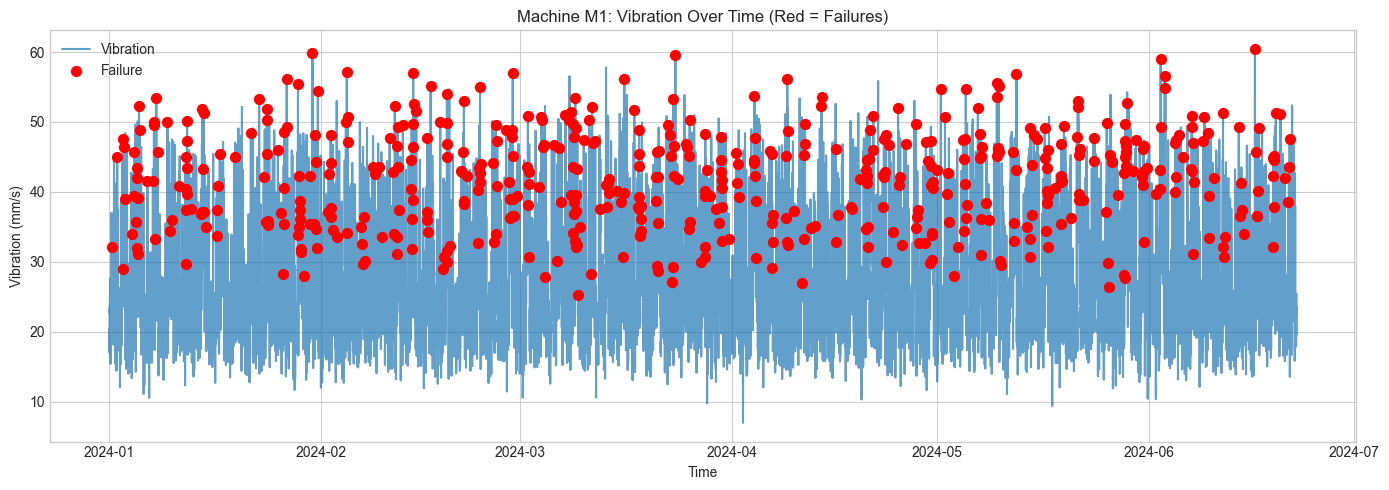

In [17]:
# Plot vibration over time with failures marked
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(m1_data.index, m1_data['vibration_mm_s'], label='Vibration', alpha=0.7)

# Mark failure points
failures = m1_data[m1_data['machine_failure'] == 1]
ax.scatter(failures.index, failures['vibration_mm_s'], 
           color='red', s=50, label='Failure', zorder=5)

ax.set_xlabel('Time')
ax.set_ylabel('Vibration (mm/s)')
ax.set_title(f'Machine {machine_id}: Vibration Over Time (Red = Failures)')
ax.legend()
plt.tight_layout()
plt.show()

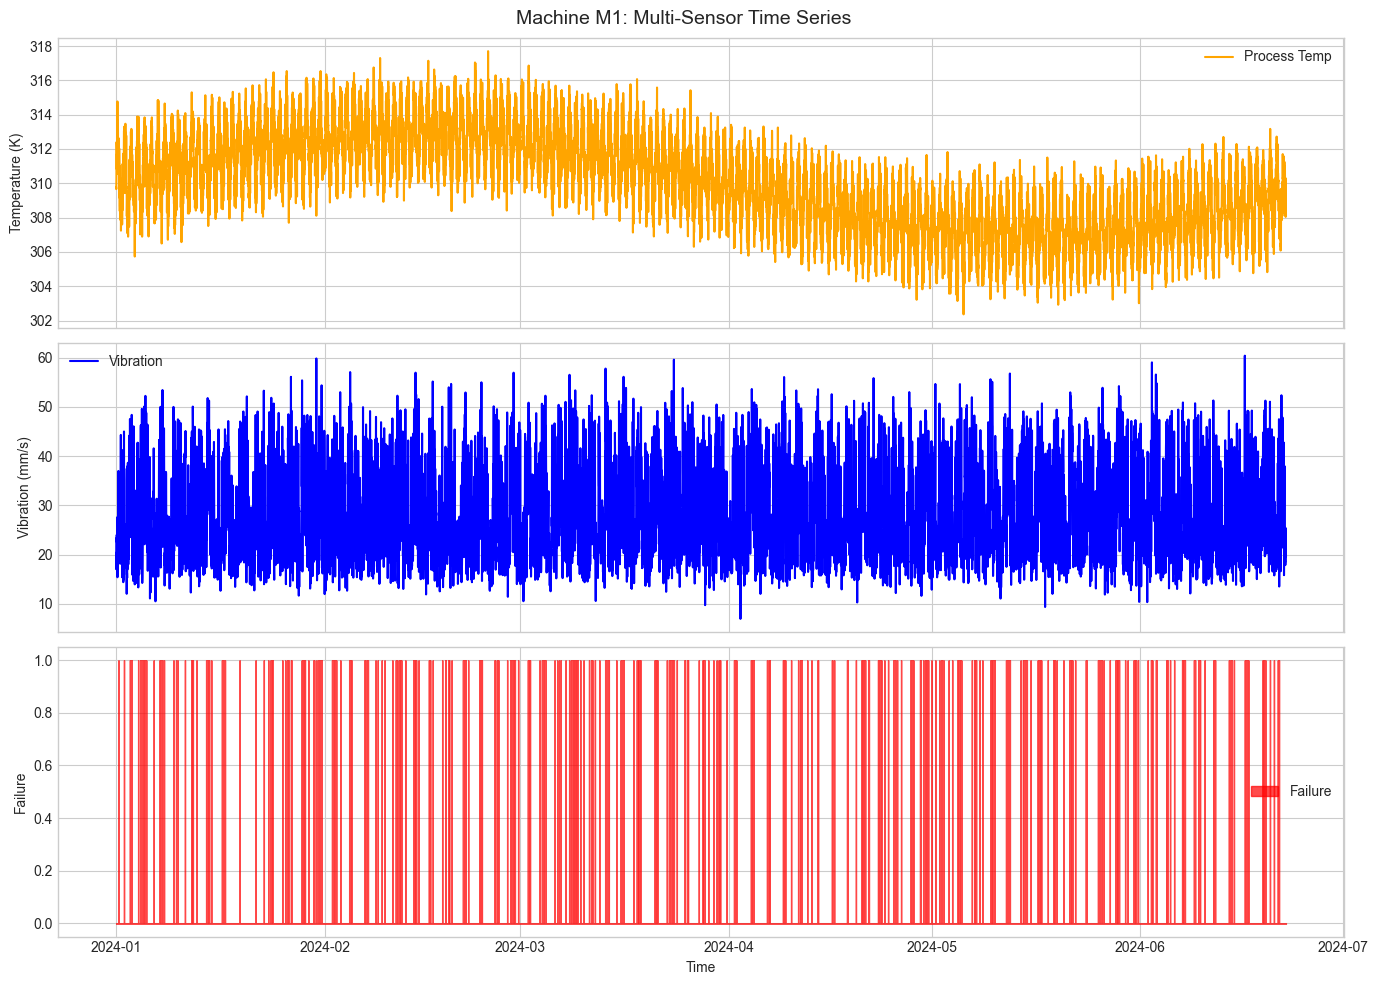

In [18]:
# Multi-sensor view
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Temperature
axes[0].plot(m1_data.index, m1_data['process_temperature_K'], label='Process Temp', color='orange')
axes[0].set_ylabel('Temperature (K)')
axes[0].legend()

# Vibration
axes[1].plot(m1_data.index, m1_data['vibration_mm_s'], label='Vibration', color='blue')
axes[1].set_ylabel('Vibration (mm/s)')
axes[1].legend()

# Failure indicator
axes[2].fill_between(m1_data.index, m1_data['machine_failure'], 
                     step='mid', alpha=0.7, color='red', label='Failure')
axes[2].set_ylabel('Failure')
axes[2].set_xlabel('Time')
axes[2].legend()

plt.suptitle(f'Machine {machine_id}: Multi-Sensor Time Series', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

Which sensors are most correlated with failures?

In [19]:
# Calculate correlation with target
numeric_cols = sys_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'machine_failure']

correlations = sys_df[numeric_cols + ['machine_failure']].corr()['machine_failure'].drop('machine_failure')
correlations = correlations.sort_values(ascending=False)

print("=== Correlation with Machine Failure ===")
print(correlations.round(3))

=== Correlation with Machine Failure ===
failure_TWF                0.804
network_latency_ms         0.407
edge_processing_time_ms    0.380
vibration_mm_s             0.363
failure_PWF                0.331
failure_OSF                0.322
failure_HDF                0.322
pressure_psi               0.228
tool_wear_min              0.222
failure_RNF                0.182
torque_Nm                  0.014
rotational_speed_rpm       0.013
air_temperature_K         -0.002
process_temperature_K     -0.015
fuzzy_pid_output          -0.406
Name: machine_failure, dtype: float64


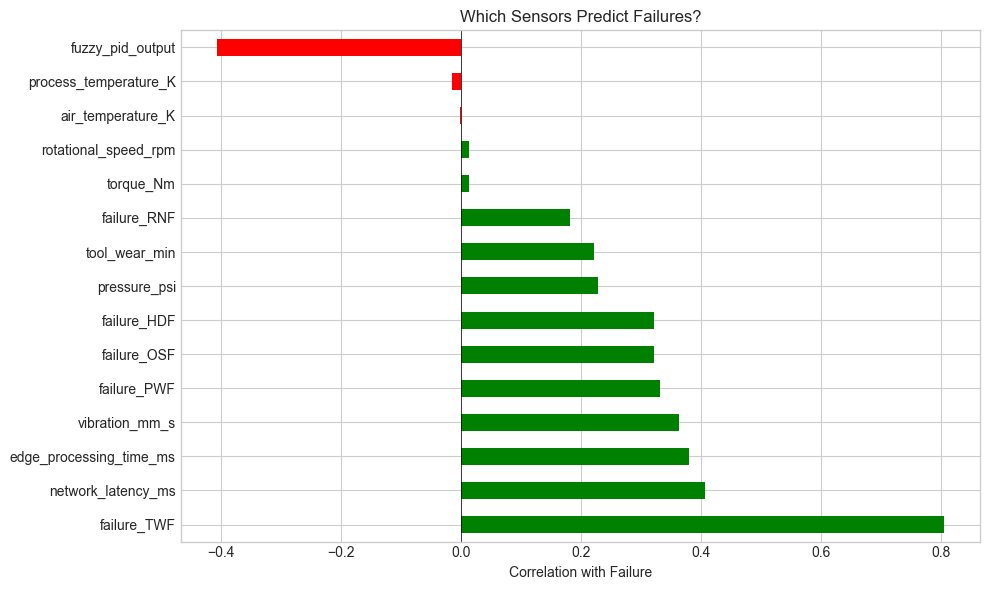

In [20]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlations]
correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Correlation with Failure')
ax.set_title('Which Sensors Predict Failures?')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. Summary

### What We Learned:
1. **Data size**: 50,000 rows, 5 machines, ~35 days of data
2. **Imbalanced target**: Only ~5% are failures (need SMOTE)
3. **Key predictors**: Vibration, temperature, tool wear correlate with failures
4. **Time patterns**: Failures cluster in time (degradation sequences)

### Next Steps:
- **Notebook 2**: Streaming & Quality Gates (Stage 1)
- **Notebook 3**: Feature Engineering (rolling windows, lags)
- **Notebook 4**: Model Training (XGBoost + SMOTE)
- **Notebook 5**: Evaluation & Deployment